In [17]:
# Enable autoreload of imported modules

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
# Compute normalized columns

def normalize_data_columns(df):
    columns = ["n_docs", "dist_smooth_to_prev_smooth", "dispersion", "curvature", "drift_from_baseline"]

    for col in columns:
        df[f"{col}_norm"] = df[col]/df[col].sum()
    
    return df

def normalize_data_columns_per_dataset(df):
    """
    Normalize data per dataset and per group.
    That is, makes column `c` (e.g.: n_docs) in dataset `d` (e.g.: helene) and group `g` (e.g.: event, background) sum to 1.
    """
    columns = ["n_docs", "dist_smooth_to_prev_smooth", "dispersion", "curvature", "drift_from_baseline"]

    cols_norm = [f"{col}_norm" for col in columns]

    df[cols_norm] = df.groupby(["event_name", "group"])[columns].transform(
        lambda x: x/x.sum()
    )
    return df





In [19]:
import pandas as pd
from pathlib import Path

datasets = [d.name for d in Path("output/").iterdir() if d.is_dir()]

data = []  # Store dataset results from temporal analysis
xlim = (-7,30)  # Define plot limits


# Load event labels
with open("data/event_labels.csv") as fin:
    event_labels = {}
    for line in fin:
        event, label = line.strip().split(",",1)
        event_labels[event] = label

for dataset in datasets:
    data_dir = Path(f"output/{dataset}")

    # Load daily files
    event_df = pd.read_csv(data_dir.joinpath("daily_event.csv"))
    bg_df = pd.read_csv(data_dir.joinpath("daily_background.csv"))
    overall_df = pd.read_csv(data_dir.joinpath("daily_overall.csv"))
    dfs = [overall_df, bg_df, event_df]  # Get all dfs
    
    event_df["group"] = "event"
    bg_df["group"] = "background"
    overall_df["group"] = "overall"
    event_df["event_type"] = event_labels[dataset]
    bg_df["event_type"] = event_labels[dataset]

    ds_df = pd.concat((overall_df, bg_df, event_df))
    ds_df["event_name"] = dataset
    ds_df["event_type"] = event_labels[dataset]
    data.append(ds_df)

df = pd.concat(data)
df = normalize_data_columns_per_dataset(df)

df.to_csv("temporal_results_all.csv", index=None)


In [20]:
import matplotlib.pyplot as plt

def plot_onset_line(ymin=-1, ymax=1, linestyles="-", colors="black", linewidth=1, label="Event onset", ax=None):
    if ax is None:
        plt.autoscale(False)  # Set autoscale before drawing vertical line
        plt.vlines((0), ymin=ymin, ymax=ymax, linestyles=linestyles, colors=colors, linewidths=linewidth, label=label)
    else:
        ax.axvline(x=0, linestyle=linestyles, color=colors, linewidth=linewidth, label=label)

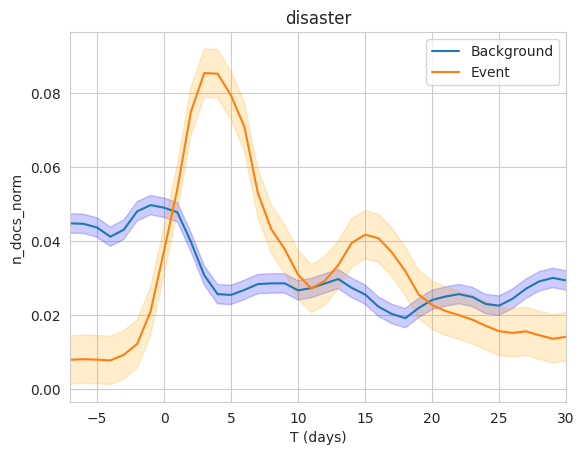

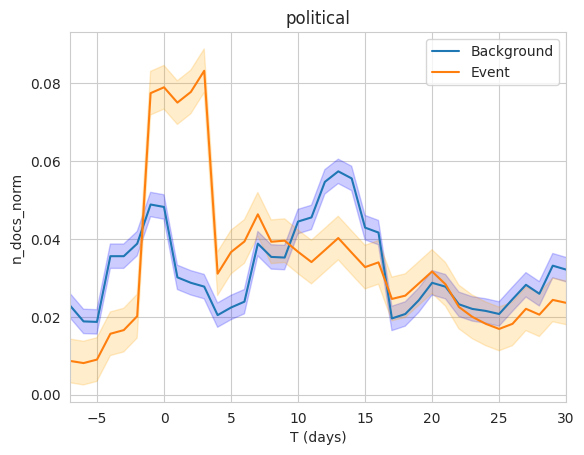

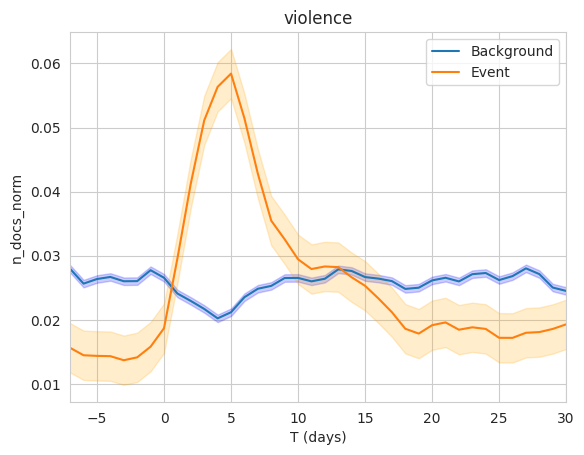

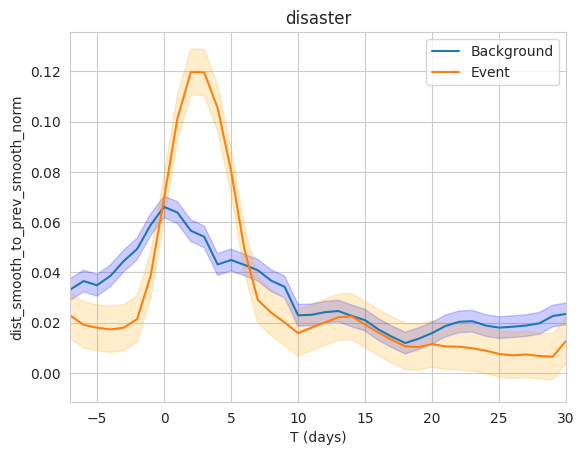

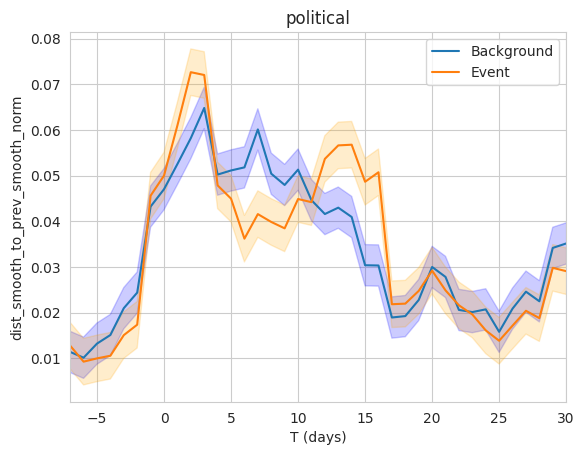

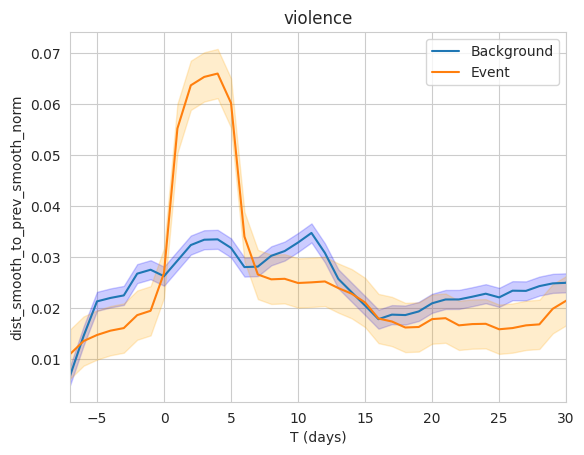

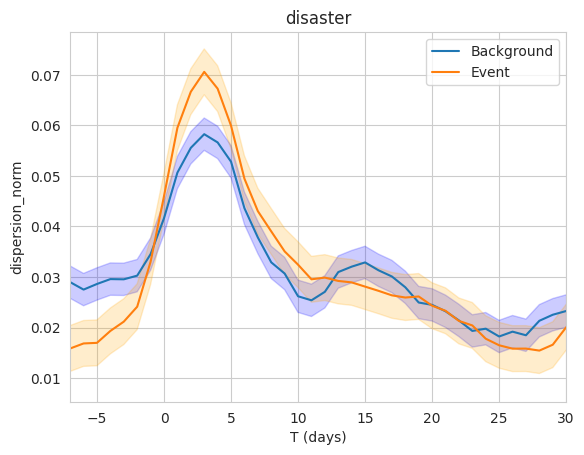

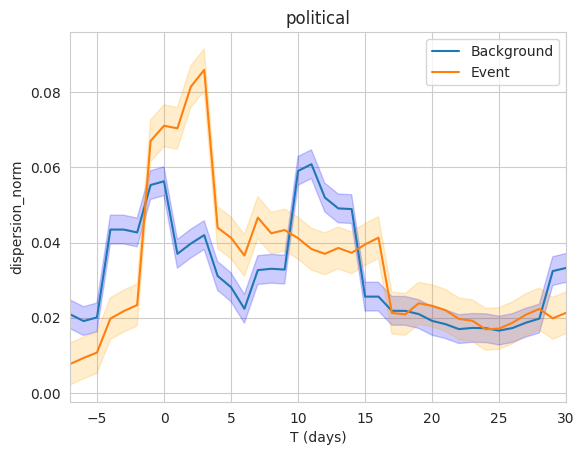

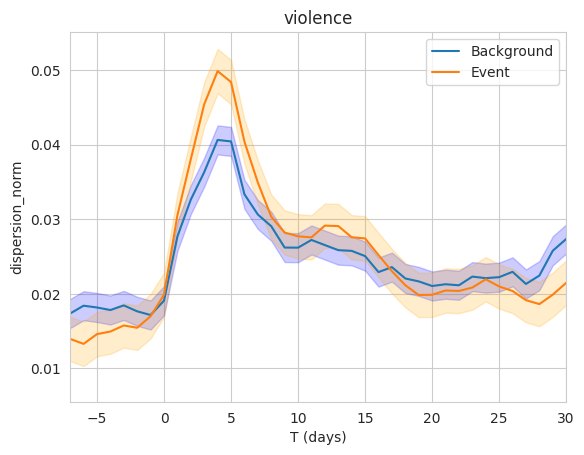

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
from scipy.stats import sem
import numpy as np

output_dir = Path("results/")
output_dir.mkdir(exist_ok=True)

def plot_event_background_timeseries(df, plot_error=True,
                                     error="sem"):

    event_types = sorted(df['event_type'].unique())
    window=5
    x = np.array(sorted(df['dt'].unique()))

    cols = ['n_docs_norm', 'dist_smooth_to_prev_smooth_norm', 'dispersion_norm']

    for y_col in cols:
        for evt_t in event_types:
            df_t = df[(df['event_type']==evt_t)&(df['group']!='overall')]
            df_t = df_t.sort_values('dt')
            avg_dt = df_t.groupby(['group', 'dt'])[y_col].mean()
            std_dt = df_t.groupby(['group', 'dt'])[y_col].std()

            # Get values for each group
            y_bg = avg_dt.background.rolling(window=window, min_periods=1).mean()
            y_event = avg_dt.event.rolling(window=window, min_periods=1).mean()
            
            if error == "std":
                bg_err = std_dt.background.rolling(window=window, min_periods=1).mean()
                event_err = std_dt.event.rolling(window=window, min_periods=1).mean()
            elif error == "sem":
                bg_err = 2*sem(y_bg, nan_policy="omit")  # Use standard error of mean
                event_err = 2*sem(y_event, nan_policy="omit")

            fig, ax = plt.subplots();
            ax.set_xlim(*xlim)

            if plot_error:
                ax.fill_between(x[:len(y_bg)], y_bg-bg_err, y_bg+bg_err, color='blue', alpha=0.2)
                ax.fill_between(x[:len(y_event)], y_event-event_err, y_event+event_err, color='orange', alpha=0.2)

            ax.plot(x[:len(y_bg)], y_bg, label="Background");
            ax.plot(x[:len(y_event)], y_event, label="Event")


            ax.set_title(evt_t);
            ax.legend();
            ax.set_xlabel("T (days)")
            ax.set_ylabel(y_col)
            fig.savefig(output_dir.joinpath(f"{y_col}_{evt_t}.pdf"));


plot_event_background_timeseries(df)